In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ramezaboud/data-sets/final_english_ready_dataset.csv
/kaggle/input/datasets/ramezaboud/data-sets/final_english_ready.csv
/kaggle/input/datasets/ramezaboud/data-sets/final_arabic_ready.csv
/kaggle/input/datasets/ramezaboud/data-sets/final_english_ready2.csv
/kaggle/input/datasets/ramezaboud/best-model2/best_model/config.json
/kaggle/input/datasets/ramezaboud/best-model2/best_model/tokenizer.json
/kaggle/input/datasets/ramezaboud/best-model2/best_model/training_state.pt
/kaggle/input/datasets/ramezaboud/best-model2/best_model/tokenizer_config.json
/kaggle/input/datasets/ramezaboud/best-model2/best_model/model.safetensors


In [2]:
import pandas as pd

df_en = pd.read_csv("/kaggle/input/datasets/ramezaboud/data-sets/final_english_ready_dataset.csv")
df_ar = pd.read_csv("/kaggle/input/datasets/ramezaboud/data-sets/final_arabic_ready.csv")

print(df_en.shape, df_en['label'].value_counts().to_dict())
print(df_ar.shape, df_ar['label'].value_counts().to_dict())

(475996, 3) {1: 248820, 0: 227176}
(577229, 2) {0: 323001, 1: 254228}


In [3]:
print(df_ar.columns.tolist())
print(df_en.columns.tolist())

['text', 'label']
['text', 'label', 'word_count']


In [4]:
df_en = df_en[['text', 'label']]

In [5]:
human_ar = df_ar[df_ar['label'] == 0].sample(n=254228, random_state=42)
ai_ar    = df_ar[df_ar['label'] == 1]

df_ar = pd.concat([human_ar, ai_ar]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df_ar['label'].value_counts())
print("Total:", len(df_ar))

label
0    254228
1    254228
Name: count, dtype: int64
Total: 508456


In [6]:
# df = pd.concat([df_en, df_ar], ignore_index=True)
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# print(f"Total   : {len(df):,}")
# print(f"\nLabel dist:\n{df['label'].value_counts()}")

Total   : 984,452

Label dist:
label
1    503048
0    481404
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

# Split at text level — قبل الـ tokenization (no leakage)
df_train, df_temp = train_test_split(
    df, test_size=0.20, stratify=df['label'], random_state=42
)

df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp['label'], random_state=42
)

print(f"Train : {len(df_train):,} | {df_train['label'].value_counts().to_dict()}")
print(f"Val   : {len(df_val):,}   | {df_val['label'].value_counts().to_dict()}")
print(f"Test  : {len(df_test):,}  | {df_test['label'].value_counts().to_dict()}")

Train : 787,561 | {1: 402438, 0: 385123}
Val   : 98,445   | {1: 50305, 0: 48140}
Test  : 98,446  | {1: 50305, 0: 48141}


In [ ]:
# حدد اللغة قبل الدمج
df_en['lang'] = 'en'
df_ar['lang'] = 'ar'

df = pd.concat([df_en, df_ar], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total   : {len(df):,}")
print(f"\nLabel dist:\n{df['label'].value_counts()}")
print(f"\nLang dist:\n{df['lang'].value_counts()}")

In [8]:
print("=" * 50)
print("COMBINED DATASET — INSPECTION")
print("=" * 50)

print(f"\nShape      : {df.shape}")
print(f"Duplicates : {df.duplicated(subset=['text']).sum():,}")
print(f"Nulls      :\n{df.isnull().sum()}")

print("\n" + "=" * 50)
print("SAMPLES — HUMAN")
print("=" * 50)
for i, row in df[df['label'] == 0].sample(3, random_state=42).iterrows():
    print(f"\n[{i}] {row['text'][:200]}")
    print("-" * 40)

print("\n" + "=" * 50)
print("SAMPLES — AI")
print("=" * 50)
for i, row in df[df['label'] == 1].sample(3, random_state=42).iterrows():
    print(f"\n[{i}] {row['text'][:200]}")
    print("-" * 40)

print("\n" + "=" * 50)
print("LANGUAGE MIX CHECK")
print("=" * 50)
print(f"English rows : {len(df_en):,}")
print(f"Arabic rows  : {len(df_ar):,}")
print(f"Total        : {len(df):,}")

COMBINED DATASET — INSPECTION

Shape      : (984452, 2)
Duplicates : 1
Nulls      :
text     0
label    0
dtype: int64

SAMPLES — HUMAN

[814034] I should have had no trouble. Of course people laughed and one or two men said something to me but I just went on and didn't answer." Mrs. Lang shook her head. "Don't do it again. It wouldn't be exact
----------------------------------------

[860774] In this paper we prove the following new sufficient condition for a digraph to be Hamiltonian: {\it Let $D$ be a 2-strong digraph of order $n\geq 9$. If $n-1$ vertices of $D$ have degrees at least $n+
----------------------------------------

[399120] الثقافي الكبير للمسيحية في اليابان من خلال المدارس وغيرها من أشكال التأثير المختلفة. يذكر أن 7 دول ذات أغلبية مسيحية من أصل 10 تتربع على قائمة الدول العشرة الأكثر تعليما في العالم من حيث نسبة السكان ا
----------------------------------------

SAMPLES — AI

[795145] أظهرت دراسة حديثة أجرتها غرفة التجارة الألمانية للتو غدا الجمعة، أن أغلب الشركات الأ

In [9]:
df.head()

,text,label
0,أعتمد علم جمهورية باشكورستان (بالبشكيرية: Башҡ...,0
1,"In this paper, we present a novel approach to ...",1
2,رغم إعجابي الشديد باللمسة السحرية التي تضفيها ...,1
3,نورالدين ثلاج-أخبارنا المغربية بالرغم من تعيين...,0
4,ناصر صنهات ساير العصيمي نائب سابق في مجلس الأم...,0


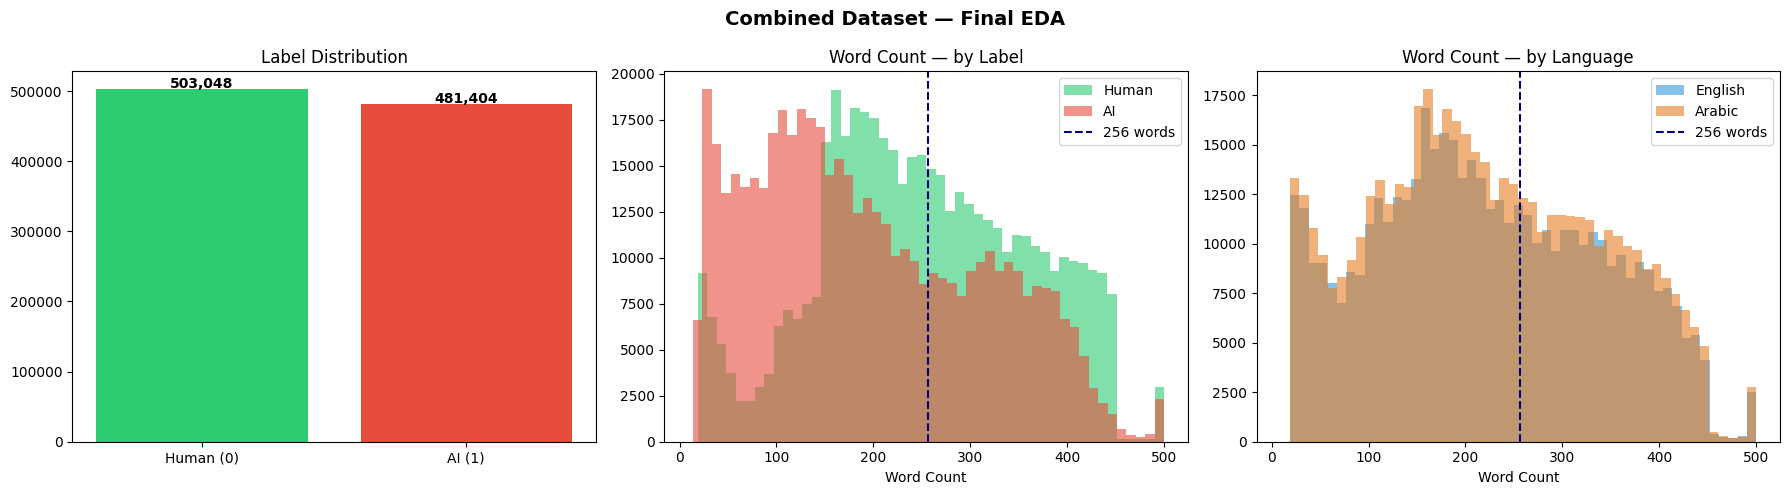

In [10]:
import matplotlib.pyplot as plt
import numpy as np

df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Combined Dataset — Final EDA", fontsize=14, fontweight="bold")

# 1. Label Distribution
counts = df['label'].value_counts()
axes[0].bar(["Human (0)", "AI (1)"], counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Label Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

# 2. Word Count Distribution — by label
for label, color, name in [(0, "#2ecc71", "Human"), (1, "#e74c3c", "AI")]:
    subset = df[df['label'] == label]['word_count']
    axes[1].hist(subset.clip(upper=500), bins=50, alpha=0.6, color=color, label=name)
axes[1].axvline(256, color="navy", linestyle="--", linewidth=1.5, label="256 words")
axes[1].set_title("Word Count — by Label")
axes[1].set_xlabel("Word Count")
axes[1].legend()

# 3. Word Count Distribution — by language
for lang, color, name in [("en", "#3498db", "English"), ("ar", "#e67e22", "Arabic")]:
    subset = df[df['lang'] == lang]['word_count']
    axes[2].hist(subset.clip(upper=500), bins=50, alpha=0.6, color=color, label=name)
axes[2].axvline(256, color="navy", linestyle="--", linewidth=1.5, label="256 words")
axes[2].set_title("Word Count — by Language")
axes[2].set_xlabel("Word Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("combined_eda_final.png", dpi=150)
plt.show()

In [11]:
print("=== English ===")
wc_en = df[df['lang'] == 'en']['word_count']
print(f"  Max    : {wc_en.max():,}")
print(f"  > 512  : {(wc_en > 512).sum():,} ({(wc_en > 512).mean()*100:.1f}%)")

print("\n=== Arabic ===")
wc_ar = df[df['lang'] == 'ar']['word_count']
print(f"  Max    : {wc_ar.max():,}")
print(f"  > 512  : {(wc_ar > 512).sum():,} ({(wc_ar > 512).mean()*100:.1f}%)")

=== English ===
  Max    : 3,353
  > 512  : 2,224 (0.5%)

=== Arabic ===
  Max    : 4,337
  > 512  : 2,428 (0.5%)


In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

class AIDetectionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.texts     = df['text'].tolist()
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Test
sample_dataset = AIDetectionDataset(df_train.head(5), tokenizer)
sample = sample_dataset[0]
print(f"input_ids shape     : {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"label               : {sample['label']}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

input_ids shape     : torch.Size([512])
attention_mask shape: torch.Size([512])
label               : 0


In [13]:
train_dataset = AIDetectionDataset(df_train, tokenizer)
val_dataset   = AIDetectionDataset(df_val,   tokenizer)
test_dataset  = AIDetectionDataset(df_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

Train batches : 49,223
Val batches   : 6,153
Test batches  : 6,153


In [14]:
from transformers import AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2,
    id2label={0: "human", 1: "ai"},
    label2id={"human": 0, "ai": 1}
)

model = model.to(device)

# تحقق
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Device: cuda


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 278,045,186
Trainable params: 278,045,186


In [15]:
# Multi-GPU
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs ✅")
    model = torch.nn.DataParallel(model)

model = model.to(device)
print(f"Device: {device}")
print(f"GPUs available: {torch.cuda.device_count()}")

Using 2 GPUs ✅
Device: cuda
GPUs available: 2


In [16]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
EPOCHS      = 1
LR          = 2e-5
ACCUMULATION_STEPS = 2
scaler             = GradScaler()
WARMUP_STEPS = int(0.1 * len(train_loader) * EPOCHS)  # 10% من الـ total steps

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=len(train_loader) * EPOCHS
)

print(f"Epochs         : {EPOCHS}")
print(f"LR             : {LR}")
print(f"Total steps    : {len(train_loader) * EPOCHS:,}")
print(f"Warmup steps   : {WARMUP_STEPS:,}")

Epochs         : 1
LR             : 2e-05
Total steps    : 49,223
Warmup steps   : 4,922


/tmp/ipykernel_57/1787144661.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler             = GradScaler()


In [21]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler, device, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc="Training")):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        with torch.amp.autocast('cuda'):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss
            if isinstance(loss, torch.Tensor) and loss.dim() > 0:
                loss = loss.mean()
            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_loss += loss.item() * ACCUMULATION_STEPS
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    return {
        "loss": total_loss / len(loader),
        "acc":  accuracy_score(all_labels, all_preds),
        "f1":   f1_score(all_labels, all_preds, average="binary")
    }

In [18]:
def eval_epoch(model, loader, device, desc="Evaluating"):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss    = outputs.loss
                if isinstance(loss, torch.Tensor) and loss.dim() > 0:
                    loss = loss.mean()

            total_loss += loss.item()
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    return {
        "loss": total_loss / len(loader),
        "acc":  accuracy_score(all_labels, all_preds),
        "f1":   f1_score(all_labels, all_preds, average="binary")
    }

In [23]:
import os
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW

RESUME_PATH = "/kaggle/input/datasets/ramezaboud/best-model2/best_model"
#RESUME = os.path.exists(RESUME_PATH + "/training_state.pt")
RESUME = False

start_epoch = 0
best_val_f1 = 0

if RESUME:
    model = torch.nn.DataParallel(
        AutoModelForSequenceClassification.from_pretrained(RESUME_PATH).to(device)
    )
    state = torch.load(RESUME_PATH + "/training_state.pt")
    start_epoch = state['epoch'] + 1
    best_val_f1 = state['best_val_f1']
    
    # optimizer و scaler جدد تماماً
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    scaler = torch.amp.GradScaler('cuda')
    optimizer.zero_grad()
    
    print(f"✅ Resumed — epoch {start_epoch} | Best F1: {best_val_f1:.4f}")
else:
    print("🆕 Starting from scratch — Epoch 1")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Resumed — epoch 1 | Best F1: 0.9782


In [24]:
from sklearn.metrics import accuracy_score, f1_score
import shutil

for epoch in range(start_epoch, start_epoch + EPOCHS):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*50}")

    train_metrics = train_epoch(model, train_loader, optimizer, scheduler, device, scaler)
    val_metrics   = eval_epoch(model, val_loader, device, desc="Validating")

    print(f"\nTrain — Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['acc']:.4f} | F1: {train_metrics['f1']:.4f}")
    print(f"Val   — Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['acc']:.4f} | F1: {val_metrics['f1']:.4f}")

    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        model.module.save_pretrained("best_model_version_2")
        tokenizer.save_pretrained("best_model_version_2")
        torch.save({
            'epoch': epoch,
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_f1': best_val_f1,
        }, "best_model_version_2/training_state.pt")
        print(f"  ✅ Best model saved (F1: {best_val_f1:.4f})")

        shutil.make_archive("best_model_version_2", 'zip', "best_model_version_2")
        print("✅ Zip ready in Output")
    else:
        print(f"  ℹ️ No improvement (Best F1 still: {best_val_f1:.4f})")


Epoch 2/1


Training:   0%|          | 0/49223 [00:00<?, ?it/s]

/tmp/ipykernel_57/3749411718.py:26: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Validating:   0%|          | 0/6153 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Train — Loss: 0.0387 | Acc: 0.9863 | F1: 0.9866
Val   — Loss: 0.0810 | Acc: 0.9742 | F1: 0.9753
  ℹ️ No improvement (Best F1 still: 0.9782)


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from transformers import AutoModelForSequenceClassification
import torch
from transformers import AutoTokenizer
from tqdm.auto import tqdm

model = AutoModelForSequenceClassification.from_pretrained("/kaggle/input/datasets/ramezaboud/best-model2/best_model")
tokenizer = AutoTokenizer.from_pretrained("/kaggle/input/datasets/ramezaboud/best-model2/best_model")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = model.to(device)
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)
model = model.to(device)

test_dataset  = AIDetectionDataset(df_test,  tokenizer)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

test_metrics = eval_epoch(model, test_loader, device, desc="Testing")
print(f"Test — Loss: {test_metrics['loss']:.4f} | Acc: {test_metrics['acc']:.4f} | F1: {test_metrics['f1']:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import torch
from tqdm.auto import tqdm

model.eval()

# Lang mapping
df_with_lang = df.copy()
df_with_lang["lang"] = ["en"] * len(df_en) + ["ar"] * len(df_ar)
test_langs = df_with_lang.loc[df_test.index, "lang"].reset_index(drop=True)

all_preds, all_labels, all_langs = [], [], []

with torch.no_grad():
    for i, batch in enumerate(tqdm(test_loader, desc="Collecting predictions")):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=-1).cpu().numpy()

        start = i * test_loader.batch_size
        end   = start + len(preds)

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_langs.extend(test_langs.iloc[start:end].tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_langs  = np.array(all_langs)

print(f"Total: {len(all_preds):,} | EN: {(all_langs=='en').sum():,} | AR: {(all_langs=='ar').sum():,}")

# ---- Plot ----
def plot_cm(ax, cm, title, classes=["Human", "AI"]):
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    tp = cm[1,1]; fn = cm[1,0]; fp = cm[0,1]; tn = cm[0,0]
    precision_ai    = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_ai       = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_human = tn / (tn + fn) if (tn + fn) > 0 else 0
    recall_human    = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy        = (tp + tn) / cm.sum()

    thresh = cm.max() / 2.0
    labels_text = [[f"TN\n{tn:,}", f"FP\n{fp:,}"], [f"FN\n{fn:,}", f"TP\n{tp:,}"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, labels_text[i][j], ha="center", va="center",
                    fontsize=11, color="white" if cm[i,j] > thresh else "black", fontweight="bold")

    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.text(0.5, -0.28,
        f"Precision  —  Human: {precision_human:.3f}  |  AI: {precision_ai:.3f}\n"
        f"Recall     —  Human: {recall_human:.3f}  |  AI: {recall_ai:.3f}\n"
        f"Accuracy: {accuracy:.3f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=9.5, family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", fc="#f0f4ff", ec="#aabbdd", lw=1))

mask_en = all_langs == "en"
mask_ar = all_langs == "ar"

cm_en      = confusion_matrix(all_labels[mask_en], all_preds[mask_en])
cm_ar      = confusion_matrix(all_labels[mask_ar], all_preds[mask_ar])
cm_overall = confusion_matrix(all_labels, all_preds)

fig = plt.figure(figsize=(20, 6))
fig.suptitle("Confusion Matrices — XLM-RoBERTa AI Text Detector", fontsize=15, fontweight="bold", y=1.02)
gs = gridspec.GridSpec(1, 3, wspace=0.45)

plot_cm(fig.add_subplot(gs[0]), cm_en,      "🇬🇧  English Test Set")
plot_cm(fig.add_subplot(gs[1]), cm_ar,      "🇸🇦  Arabic Test Set")
plot_cm(fig.add_subplot(gs[2]), cm_overall, "🌍  Overall (EN + AR)")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# Console summary
print("\n" + "="*55)
for tag, mask in [("English", mask_en), ("Arabic", mask_ar), ("Overall", np.ones(len(all_labels), dtype=bool))]:
    y_true = all_labels[mask]; y_pred = all_preds[mask]
    print(f"\n  [{tag}]  Samples: {len(y_true):,}  |  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    for cls, lbl in [("Human", 0), ("AI", 1)]:
        p = precision_score(y_true, y_pred, pos_label=lbl, zero_division=0)
        r = recall_score(y_true, y_pred, pos_label=lbl, zero_division=0)
        f = f1_score(y_true, y_pred, pos_label=lbl, zero_division=0)
        print(f"    {cls:6s} — P: {p:.4f}  R: {r:.4f}  F1: {f:.4f}")

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("/kaggle/input/datasets/ramezaboud/best-model")
tokenizer = AutoTokenizer.from_pretrained("/kaggle/input/datasets/ramezaboud/best-model")

In [ ]:
text="First, I build real systems. My projects are not just ideas or notebooks — they have real structure, real servers, and are built to actually work. That's not common for someone still in university."

In [ ]:
import torch.nn.functional as F

inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)
prediction = outputs.logits.argmax(dim=-1).item()

probs = F.softmax(outputs.logits, dim=-1)
confidence = probs.max().item()
prediction = probs.argmax(dim=-1).item()

label = "AI" if prediction == 1 else "Human"
print(f"Prediction: {label} ({confidence:.2%})")